Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB
None

First few rows:
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29       

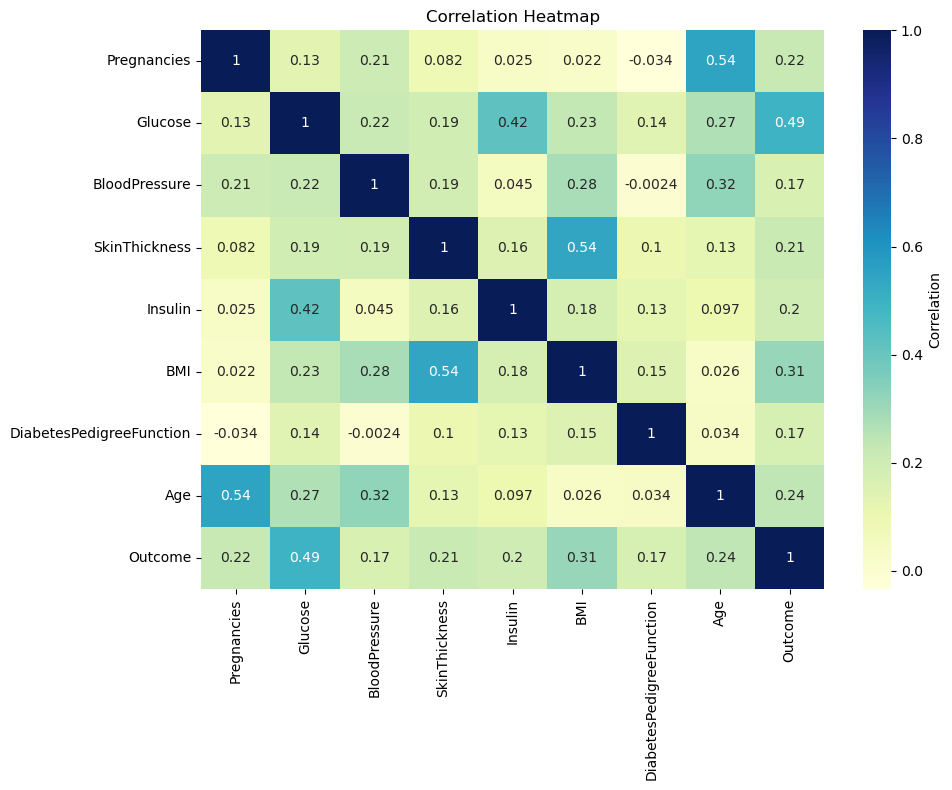

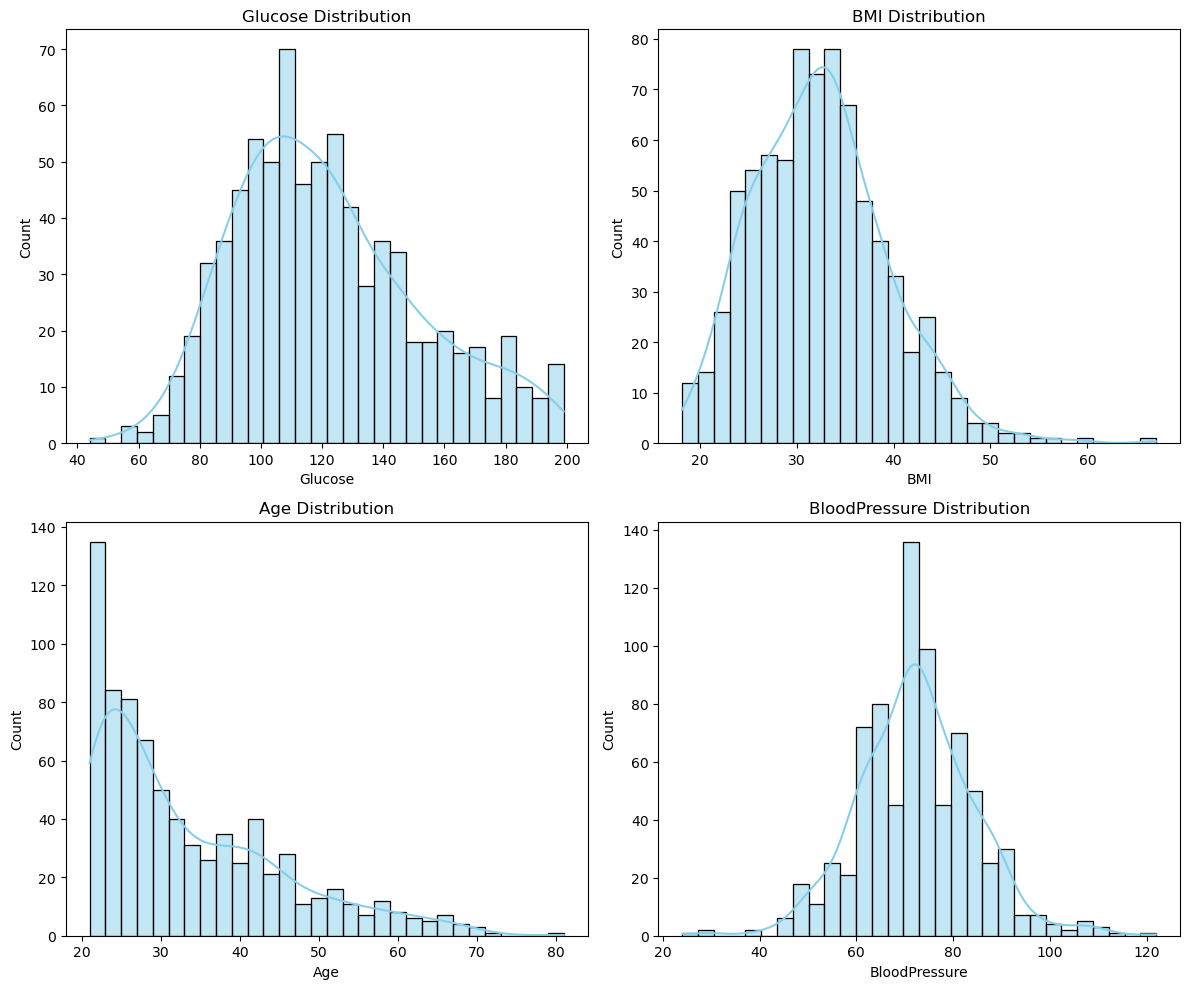

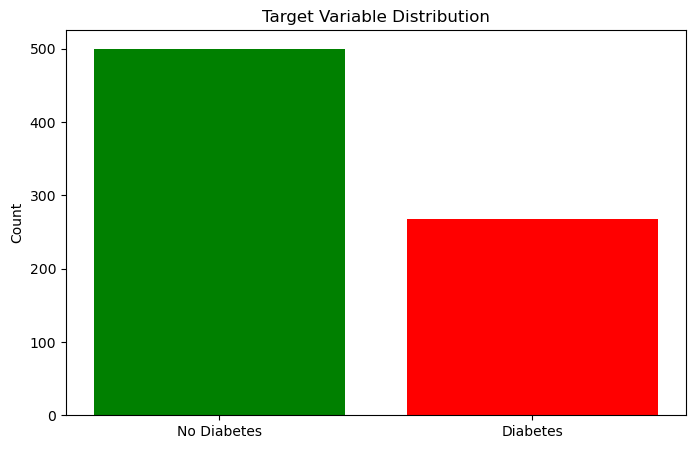


Training set size: (614, 8)
Testing set size: (154, 8)

LOGISTIC REGRESSION MODEL
Accuracy: 0.7078
AUC-ROC Score: 0.8130
F1 Score: 0.5455

Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.82      0.78       100
           1       0.60      0.50      0.55        54

    accuracy                           0.71       154
   macro avg       0.68      0.66      0.67       154
weighted avg       0.70      0.71      0.70       154


RANDOM FOREST MODEL (with Grid Search)
Best parameters: {'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 200}
Best cross-validation AUC Score: 0.8327

Test Accuracy: 0.7468
Test AUC-ROC Score: 0.8144
Test F1 Score: 0.6061

Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.85      0.81       100
           1       0.67      0.56      0.61        54

    accuracy                           0.75       154
   macro av

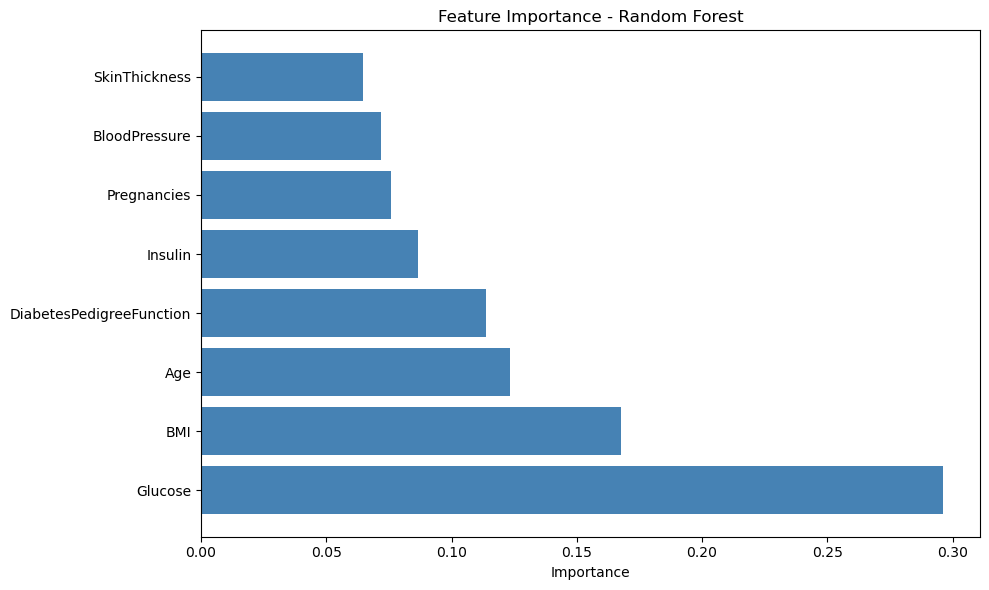

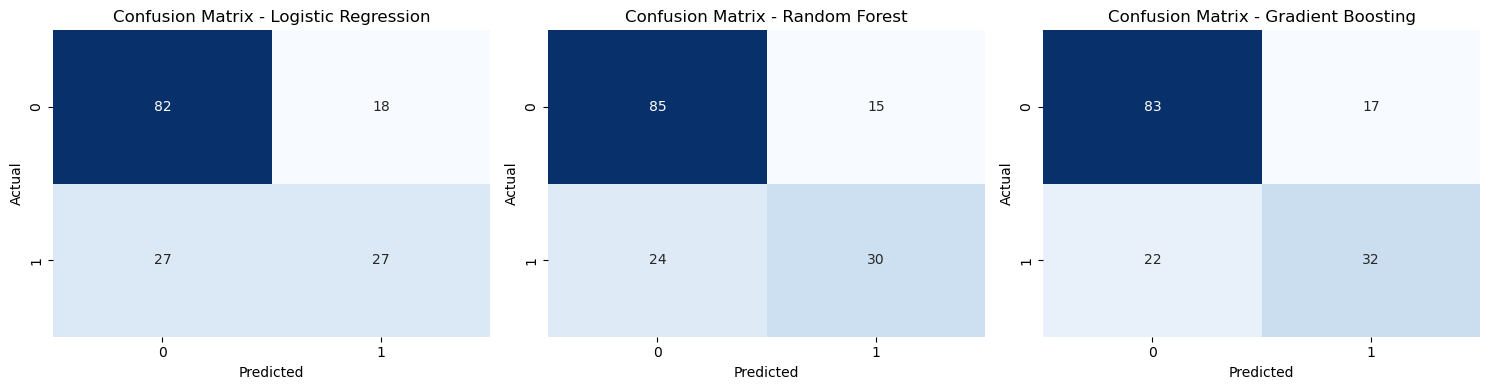

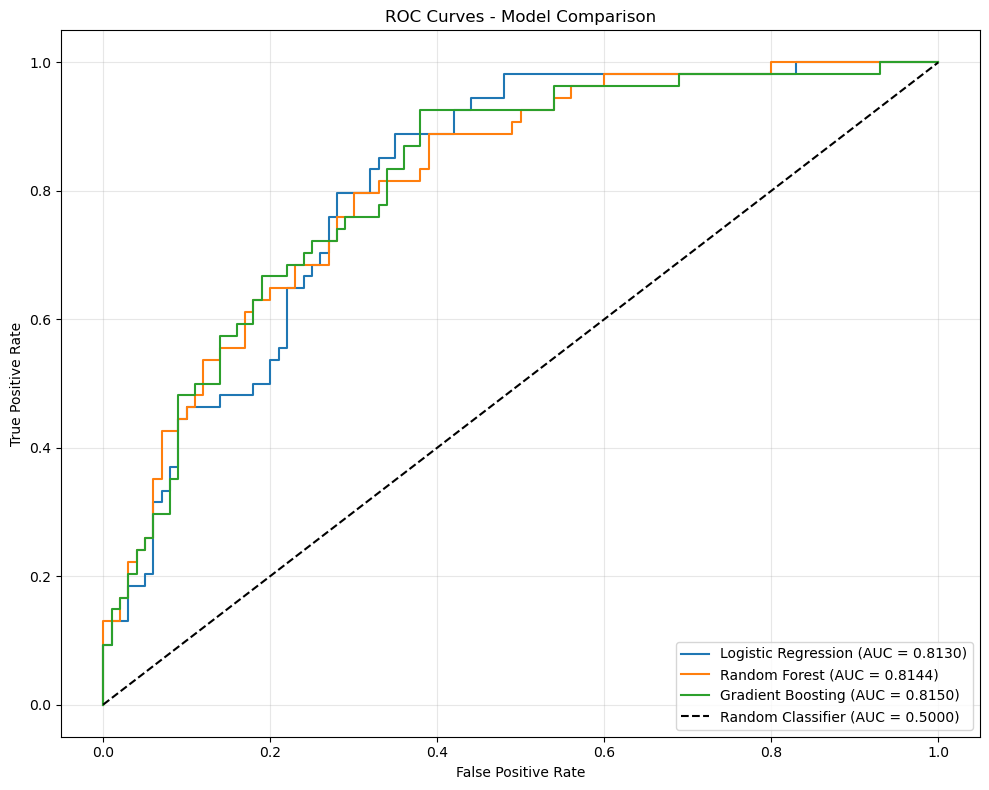

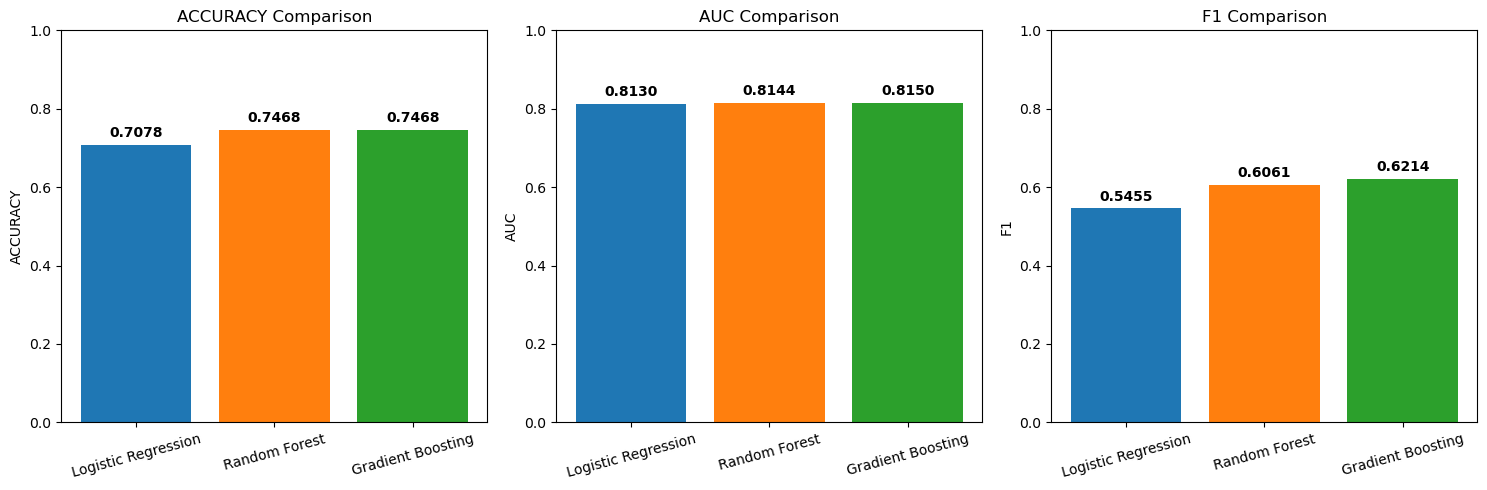


BEST MODEL: Random Forest (Optimized)
Accuracy: 0.7468
AUC-ROC: 0.8144
F1-Score: 0.6061


In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, confusion_matrix, classification_report, 
                             roc_auc_score, roc_curve, auc, precision_recall_curve, f1_score)
import warnings
warnings.filterwarnings('ignore')

# ===================== DATA LOADING =====================
dataset = pd.read_csv("./diabetes.csv")
print("Dataset Info:")
print(dataset.info())
print("\nFirst few rows:")
print(dataset.head())
print("\nDataset Statistics:")
print(dataset.describe())

# ===================== DATA PREPROCESSING =====================
# Replace zeroes with NaN for specific columns
cols_to_fix = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
for col in cols_to_fix:
    dataset[col] = dataset[col].replace(0, np.nan)

# Fill missing values with median
for col in cols_to_fix:
    dataset[col].fillna(dataset[col].median(), inplace=True)

print("\nMissing values after imputation:")
print(dataset.isnull().sum())

# ===================== EXPLORATORY DATA ANALYSIS =====================
# Correlation Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(dataset.corr(), annot=True, cmap="YlGnBu", cbar_kws={'label': 'Correlation'})
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

# Distribution plots
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

cols_plot = ['Glucose', 'BMI', 'Age', 'BloodPressure']
for idx, col in enumerate(cols_plot):
    ax = axes[idx//2, idx%2]
    sns.histplot(dataset[col], kde=True, bins=30, ax=ax, color='skyblue')
    ax.set_title(f"{col} Distribution")

plt.tight_layout()
plt.show()

# Outcome distribution
plt.figure(figsize=(8, 5))
outcome_counts = dataset['Outcome'].value_counts()
plt.bar(['No Diabetes', 'Diabetes'], outcome_counts.values, color=['green', 'red'])
plt.title("Target Variable Distribution")
plt.ylabel("Count")
plt.show()

# ===================== FEATURE ENGINEERING & SCALING =====================
# Features and target
X = dataset.drop("Outcome", axis=1)
y = dataset["Outcome"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"\nTraining set size: {X_train_scaled.shape}")
print(f"Testing set size: {X_test_scaled.shape}")

# ===================== MODEL TRAINING & EVALUATION =====================
models = {}
results = {}

# 1. Logistic Regression
print("\n" + "="*60)
print("LOGISTIC REGRESSION MODEL")
print("="*60)
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_scaled, y_train)
y_pred_lr = lr_model.predict(X_test_scaled)
y_pred_proba_lr = lr_model.predict_proba(X_test_scaled)[:, 1]

lr_accuracy = accuracy_score(y_test, y_pred_lr)
lr_auc = roc_auc_score(y_test, y_pred_proba_lr)
lr_f1 = f1_score(y_test, y_pred_lr)

print(f"Accuracy: {lr_accuracy:.4f}")
print(f"AUC-ROC Score: {lr_auc:.4f}")
print(f"F1 Score: {lr_f1:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr))

models['Logistic Regression'] = lr_model
results['Logistic Regression'] = {
    'accuracy': lr_accuracy,
    'auc': lr_auc,
    'f1': lr_f1,
    'predictions': y_pred_lr,
    'proba': y_pred_proba_lr
}

# 2. Random Forest Classifier with Hyperparameter Tuning
print("\n" + "="*60)
print("RANDOM FOREST MODEL (with Grid Search)")
print("="*60)

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

rf_base = RandomForestClassifier(random_state=42, n_jobs=-1)
grid_search_rf = GridSearchCV(rf_base, param_grid, cv=5, scoring='roc_auc', n_jobs=-1)
grid_search_rf.fit(X_train_scaled, y_train)

print(f"Best parameters: {grid_search_rf.best_params_}")
print(f"Best cross-validation AUC Score: {grid_search_rf.best_score_:.4f}")

rf_model = grid_search_rf.best_estimator_
y_pred_rf = rf_model.predict(X_test_scaled)
y_pred_proba_rf = rf_model.predict_proba(X_test_scaled)[:, 1]

rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_auc = roc_auc_score(y_test, y_pred_proba_rf)
rf_f1 = f1_score(y_test, y_pred_rf)

print(f"\nTest Accuracy: {rf_accuracy:.4f}")
print(f"Test AUC-ROC Score: {rf_auc:.4f}")
print(f"Test F1 Score: {rf_f1:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

# Feature Importance
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nFeature Importance:")
print(feature_importance)

models['Random Forest'] = rf_model
results['Random Forest'] = {
    'accuracy': rf_accuracy,
    'auc': rf_auc,
    'f1': rf_f1,
    'predictions': y_pred_rf,
    'proba': y_pred_proba_rf
}

# 3. Gradient Boosting Classifier
print("\n" + "="*60)
print("GRADIENT BOOSTING MODEL")
print("="*60)

gb_model = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, 
                                       max_depth=5, random_state=42)
gb_model.fit(X_train_scaled, y_train)
y_pred_gb = gb_model.predict(X_test_scaled)
y_pred_proba_gb = gb_model.predict_proba(X_test_scaled)[:, 1]

gb_accuracy = accuracy_score(y_test, y_pred_gb)
gb_auc = roc_auc_score(y_test, y_pred_proba_gb)
gb_f1 = f1_score(y_test, y_pred_gb)

print(f"Accuracy: {gb_accuracy:.4f}")
print(f"AUC-ROC Score: {gb_auc:.4f}")
print(f"F1 Score: {gb_f1:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_gb))

models['Gradient Boosting'] = gb_model
results['Gradient Boosting'] = {
    'accuracy': gb_accuracy,
    'auc': gb_auc,
    'f1': gb_f1,
    'predictions': y_pred_gb,
    'proba': y_pred_proba_gb
}

# ===================== CROSS-VALIDATION =====================
print("\n" + "="*60)
print("CROSS-VALIDATION SCORES (5-Fold)")
print("="*60)

for model_name, model in models.items():
    cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='roc_auc')
    print(f"\n{model_name}:")
    print(f"  Cross-Validation Scores: {cv_scores}")
    print(f"  Mean Score: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")

# ===================== MODEL COMPARISON =====================
print("\n" + "="*60)
print("MODEL COMPARISON")
print("="*60)

comparison_df = pd.DataFrame(results).T[['accuracy', 'auc', 'f1']]
print(comparison_df)

# ===================== VISUALIZATIONS =====================
# Feature Importance Plot
plt.figure(figsize=(10, 6))
plt.barh(feature_importance['Feature'], feature_importance['Importance'], color='steelblue')
plt.xlabel('Importance')
plt.title('Feature Importance - Random Forest')
plt.tight_layout()
plt.show()

# Confusion Matrices
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for idx, (model_name, predictions) in enumerate([('Logistic Regression', y_pred_lr), 
                                                   ('Random Forest', y_pred_rf),
                                                   ('Gradient Boosting', y_pred_gb)]):
    cm = confusion_matrix(y_test, predictions)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx], cbar=False)
    axes[idx].set_xlabel('Predicted')
    axes[idx].set_ylabel('Actual')
    axes[idx].set_title(f'Confusion Matrix - {model_name}')

plt.tight_layout()
plt.show()

# ROC Curves
plt.figure(figsize=(10, 8))

for model_name, proba in [('Logistic Regression', y_pred_proba_lr), 
                          ('Random Forest', y_pred_proba_rf),
                          ('Gradient Boosting', y_pred_proba_gb)]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{model_name} (AUC = {roc_auc:.4f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier (AUC = 0.5000)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves - Model Comparison')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Model Performance Comparison
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

metrics = ['accuracy', 'auc', 'f1']
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']

for idx, metric in enumerate(metrics):
    values = [results[model][metric] for model in results.keys()]
    axes[idx].bar(results.keys(), values, color=colors)
    axes[idx].set_ylabel(metric.upper())
    axes[idx].set_title(f'{metric.upper()} Comparison')
    axes[idx].set_ylim([0, 1])
    for i, v in enumerate(values):
        axes[idx].text(i, v + 0.02, f'{v:.4f}', ha='center', fontweight='bold')
    axes[idx].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("BEST MODEL: Random Forest (Optimized)")
print("="*60)
print(f"Accuracy: {rf_accuracy:.4f}")
print(f"AUC-ROC: {rf_auc:.4f}")
print(f"F1-Score: {rf_f1:.4f}")
